In [21]:
%config Completer.use_jedi = False
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import seaborn as sns
import cv2
import random
import os
import imageio
import plotly.graph_objects as go
import plotly.express as px
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
from collections import Counter
import platform

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, RepeatedStratifiedKFold
from imblearn.over_sampling import SMOTE

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization

import os
import time
import gzip
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     GlobalAveragePooling2D, Reshape,
                                     Multiply, Input, Layer)
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

try:
    import tensorflow_model_optimization as tfmot
    _TFMOT_AVAILABLE = True
except Exception:
    _TFMOT_AVAILABLE = False


# CUDA / GPU setup (TensorFlow akan otomatis pakai GPU bila tersedia)
print(f'TensorFlow version: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'CUDA GPU terdeteksi: {[gpu.name for gpu in gpus]}')
    except RuntimeError as e:
        print(f'Peringatan konfigurasi GPU: {e}')
else:
    print('GPU CUDA tidak terdeteksi. Training akan berjalan di CPU.')
    tf_major, tf_minor = map(int, tf.__version__.split('.')[:2])
    if platform.system() == 'Windows' and (tf_major > 2 or (tf_major == 2 and tf_minor >= 11)):
        print('Catatan: TensorFlow >= 2.11 di Windows native tidak mendukung CUDA GPU.')
        print('Solusi: pakai WSL2 + CUDA, atau gunakan TensorFlow 2.10 + CUDA 11.2 + cuDNN 8.1.')

TensorFlow version: 2.10.0
CUDA GPU terdeteksi: ['/physical_device:GPU:0']


In [27]:
import random
import numpy as np
import tensorflow as tf
import os

# ═══════════════════════════════════════════════════════════════════════════
# SET RANDOM SEED FOR REPRODUCIBILITY
# ═══════════════════════════════════════════════════════════════════════════
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Mengaktifkan determinisme untuk operasi TensorFlow jika memungkinkan
try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print(f"[INFO] Could not enable op determinism: {e}")

In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# LOAD DATA DARI DATASET_PROCESSED
# ═══════════════════════════════════════════════════════════════════════════

import cv2
import os
import numpy as np
from tensorflow.keras.utils import to_categorical

# Konfigurasi
dataset_base_path = './dataset_processed2'
img_size = 224
categories = ['Bengin cases', 'Malignant cases', 'Normal cases']

# ─────────────────────────────────────────────────────────────────────────
# TAHAP 1: VALIDASI FOLDER
# ─────────────────────────────────────────────────────────────────────────
print('═' * 70)
print('MEMVALIDASI STRUKTUR FOLDER DATASET')
print('═' * 70)

if not os.path.exists(dataset_base_path):
    raise FileNotFoundError(f'Folder {dataset_base_path} tidak ditemukan!')

print(f'✓ Folder dataset ditemukan: {os.path.abspath(dataset_base_path)}\n')

# Periksa subfolder
required_splits = ['train', 'valid', 'test']
for split in required_splits:
    split_path = os.path.join(dataset_base_path, split)
    if not os.path.isdir(split_path):
        raise FileNotFoundError(f'Folder {split_path} tidak ditemukan!')
    print(f'✓ {split.upper():<6} folder ditemukan')

# ─────────────────────────────────────────────────────────────────────────
# TAHAP 2: FUNGSI LOADING DATA
# ─────────────────────────────────────────────────────────────────────────

def load_split_data(split_folder_path, categories):
    """
    Load semua gambar dari folder split (train/valid/test)
    
    Args:
        split_folder_path: Path ke folder split (e.g., './dataset_processed/train')
        categories: List nama kategori
    
    Returns:
        X: Array gambar (N, 224, 224, 3)
        y: Array label (N,)
        filenames: List nama file untuk reference
    """
    X = []
    y = []
    filenames = []
    
    for class_idx, category in enumerate(categories):
        category_path = os.path.join(split_folder_path, category)
        
        if not os.path.isdir(category_path):
            print(f'  ⚠ Folder kategori tidak ditemukan: {category_path}')
            continue
        
        image_files = sorted([f for f in os.listdir(category_path) if f.endswith('.jpg')])
        
        for img_file in image_files:
            img_path = os.path.join(category_path, img_file)
            
            try:
                # Baca gambar dalam format BGR (default cv2)
                img = cv2.imread(img_path)
                
                if img is None:
                    print(f'  ⚠ Gagal membaca: {img_file}')
                    continue
                
                # Konversi BGR ke RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Normalisasi ke range [0, 1]
                img = img.astype(np.float32) / 255.0
                
                X.append(img)
                y.append(class_idx)
                filenames.append(img_file)
                
            except Exception as e:
                print(f'  ⚠ Error loading {img_file}: {str(e)}')
                continue
    
    return np.array(X, dtype=np.float32), np.array(y), filenames


# ─────────────────────────────────────────────────────────────────────────
# TAHAP 3: LOAD DATA DARI SETIAP SPLIT
# ─────────────────────────────────────────────────────────────────────────
print(f'\n' + '─' * 70)
print('LOADING DATA DARI FOLDER')
print('─' * 70 + '\n')

# Load training data
print('Loading TRAINING data...')
train_path = os.path.join(dataset_base_path, 'train')
X_train, y_train_labels, train_files = load_split_data(train_path, categories)
print(f'   ✓ {len(X_train)} gambar training berhasil diload')

# Load validation data
print('Loading VALIDATION data...')
valid_path = os.path.join(dataset_base_path, 'valid')
X_valid, y_valid_labels, valid_files = load_split_data(valid_path, categories)
print(f'   ✓ {len(X_valid)} gambar validation berhasil diload')

# Load test data
print('Loading TEST data...')
test_path = os.path.join(dataset_base_path, 'test')
X_test, y_test_labels, test_files = load_split_data(test_path, categories)
print(f'   ✓ {len(X_test)} gambar test berhasil diload')

# ─────────────────────────────────────────────────────────────────────────
# TAHAP 4: ONE-HOT ENCODING
# ─────────────────────────────────────────────────────────────────────────
num_classes = len(categories)
y_train = to_categorical(y_train_labels, num_classes=num_classes)
y_valid = to_categorical(y_valid_labels, num_classes=num_classes)
y_test = to_categorical(y_test_labels, num_classes=num_classes)

# ─────────────────────────────────────────────────────────────────────────
# TAHAP 5: TAMPILKAN STATISTIK
# ─────────────────────────────────────────────────────────────────────────
print(f'\n' + '═' * 70)
print('STATISTIK DATA YANG DILOAD')
print('═' * 70 + '\n')

print(f'Shape Data:')
print(f'  X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'  X_valid: {X_valid.shape}  y_valid: {y_valid.shape}')
print(f'  X_test:  {X_test.shape}   y_test:  {y_test.shape}')

print(f'\nDistribusi Label (Training):')
unique_train, counts_train = np.unique(y_train_labels, return_counts=True)
for cat_idx, count in zip(unique_train, counts_train):
    print(f'  {categories[cat_idx]:<20} : {count:4d} gambar')

print(f'\nDistribusi Label (Validation):')
unique_valid, counts_valid = np.unique(y_valid_labels, return_counts=True)
for cat_idx, count in zip(unique_valid, counts_valid):
    print(f'  {categories[cat_idx]:<20} : {count:4d} gambar')

print(f'\nDistribusi Label (Test):')
unique_test, counts_test = np.unique(y_test_labels, return_counts=True)
for cat_idx, count in zip(unique_test, counts_test):
    print(f'  {categories[cat_idx]:<20} : {count:4d} gambar')

total_samples = len(X_train) + len(X_valid) + len(X_test)
print(f'\nTotal Sampel: {total_samples}')
print(f'  Proporsi Train: {len(X_train)/total_samples*100:5.1f}%')
print(f'  Proporsi Valid: {len(X_valid)/total_samples*100:5.1f}%')
print(f'  Proporsi Test:  {len(X_test)/total_samples*100:5.1f}%')

print('\nSemua data berhasil diload dan siap untuk digunakan!')

# Verifikasi normalisasi pixel values ke range [0, 1]
print(f"\n=== PIXEL VALUE NORMALIZATION VERIFICATION ===")
print(f"X_train pixel range: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"X_valid pixel range: [{X_valid.min():.4f}, {X_valid.max():.4f}]")
print(f"X_test pixel range:  [{X_test.min():.4f}, {X_test.max():.4f}]")
print(f"✓ All pixel values normalized to [0, 1] range")



══════════════════════════════════════════════════════════════════════
MEMVALIDASI STRUKTUR FOLDER DATASET
══════════════════════════════════════════════════════════════════════
✓ Folder dataset ditemukan: d:\bintang\dataset_processed2

✓ TRAIN  folder ditemukan
✓ VALID  folder ditemukan
✓ TEST   folder ditemukan

──────────────────────────────────────────────────────────────────────
LOADING DATA DARI FOLDER
──────────────────────────────────────────────────────────────────────

Loading TRAINING data...
   ✓ 737 gambar training berhasil diload
Loading VALIDATION data...
   ✓ 158 gambar validation berhasil diload
Loading TEST data...
   ✓ 159 gambar test berhasil diload

══════════════════════════════════════════════════════════════════════
STATISTIK DATA YANG DILOAD
══════════════════════════════════════════════════════════════════════

Shape Data:
  X_train: (737, 224, 224, 3)  y_train: (737, 3)
  X_valid: (158, 224, 224, 3)  y_valid: (158, 3)
  X_test:  (159, 224, 224, 3)   y_test:  

In [46]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, 
                                      GlobalAveragePooling2D, Reshape, 
                                      Multiply, Input, Layer)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import time

# ─────────────────────────────────────────────
# 2. Custom Channel Attention Module
# ─────────────────────────────────────────────
class ChannelAttention(Layer):
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap    = GlobalAveragePooling2D()
        self.dense1 = Dense(max(1, channels // self.ratio), activation='relu')
        self.dense2 = Dense(channels, activation='sigmoid')
        self.reshape = Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, x):
        attn = self.gap(x)
        attn = self.dense1(attn)
        attn = self.dense2(attn)
        attn = self.reshape(attn)
        return Multiply()([x, attn])

    def get_config(self):
        config = super().get_config()
        config.update({'ratio': self.ratio})
        return config


# ─────────────────────────────────────────────
# 3. Bangun CNN + Attention
# ─────────────────────────────────────────────
num_classes = y_train.shape[1]

def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)

    x = Flatten()(x)
    features = Dense(16, activation='relu', name='feature_layer')(x)
    output = Dense(num_classes, activation='softmax', name='softmax_output')(features)

    return Model(inputs, output, name='CNN_Attention')

model2 = build_model(X_train.shape[1:], num_classes)
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model2.fit(
    X_train, y_train,
    epochs=30,
    batch_size=8,
    validation_data=(X_valid, y_valid),
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')],
    verbose=1
)


# ─────────────────────────────────────────────
# 5. Ekstrak Fitur dari 'feature_layer'
# ─────────────────────────────────────────────
extractor = Model(
    inputs=model2.input,
    outputs=model2.get_layer('feature_layer').output
)

# Ekstrak fitur untuk set training dan validasi
X_train_feat = extractor.predict(X_train, verbose=0)
X_val_feat   = extractor.predict(X_valid, verbose=0)

print(f"\nShape fitur train : {X_train_feat.shape}")
print(f"Shape fitur val   : {X_val_feat.shape}")


# ─────────────────────────────────────────────
# 6. Konversi Label One-Hot → Integer untuk SVM
# ─────────────────────────────────────────────
y_train_int = np.argmax(y_train, axis=1)
y_valid_int = np.argmax(y_valid, axis=1)
y_test_int  = np.argmax(y_test,  axis=1)


# ─────────────────────────────────────────────
# 7. Normalisasi Fitur
# ─────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled   = scaler.transform(X_val_feat)


# ─────────────────────────────────────────────
# 8. Latih SVM (Menggunakan data train + validasi)
# ─────────────────────────────────────────────
# Gabungkan data train dan validasi untuk melatih SVM
X_svm_train = np.vstack([X_train_scaled, X_val_scaled])
y_svm_train = np.concatenate([y_train_int, y_valid_int])

svm_clf1 = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)
start_time = time.time()
svm_clf1.fit(X_svm_train, y_svm_train)
svm_training_time = time.time() - start_time
print("\nSVM selesai dilatih pada data train + validation.")


# ─────────────────────────────────────────────
# 9. Evaluasi pada Test Set (INFERENCE)
# ─────────────────────────────────────────────
start_time = time.time()

# Langkah 1: Ekstrak fitur dari data test
X_test_feat  = extractor.predict(X_test,  verbose=0)

# Langkah 2: Normalisasi fitur test
X_test_scaled  = scaler.transform(X_test_feat)

# Langkah 3: Prediksi dengan SVM
y_pred = svm_clf1.predict(X_test_scaled)

# Hitung waktu inferensi total
inference_time = time.time() - start_time

# Hitung akurasi
test_accuracy = accuracy_score(y_test_int, y_pred)

print(f"\nShape fitur test  : {X_test_feat.shape}")
print("\n=== Hasil CNN + Attention + SVM ===")
print(f"Accuracy : {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_int, y_pred))


Epoch 1/30
93/93 [==============================] - 3s 33ms/step - loss: 0.8724 - accuracy: 0.5346 - val_loss: 0.9014 - val_accuracy: 0.5253
Epoch 2/30
93/93 [==============================] - 3s 31ms/step - loss: 0.5133 - accuracy: 0.8223 - val_loss: 0.3930 - val_accuracy: 0.8987
Epoch 3/30
93/93 [==============================] - 3s 31ms/step - loss: 0.2316 - accuracy: 0.9118 - val_loss: 0.2104 - val_accuracy: 0.9557
Epoch 4/30
93/93 [==============================] - 3s 30ms/step - loss: 0.0587 - accuracy: 0.9824 - val_loss: 0.0450 - val_accuracy: 1.0000
Epoch 5/30
93/93 [==============================] - 3s 31ms/step - loss: 0.0517 - accuracy: 0.9932 - val_loss: 0.0723 - val_accuracy: 0.9873
Epoch 6/30
93/93 [==============================] - 3s 30ms/step - loss: 0.0215 - accuracy: 0.9973 - val_loss: 0.0224 - val_accuracy: 0.9937
Epoch 7/30
93/93 [==============================] - 3s 30ms/step - loss: 0.0132 - accuracy: 0.9973 - val_loss: 0.0289 - val_accuracy: 0.9937
Epoch 8/30
93

In [51]:
from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix, roc_auc_score)
from sklearn.preprocessing import label_binarize
import numpy as np

# ─────────────────────────────────────────────
# Persiapan
# ─────────────────────────────────────────────
y_pred       = svm_clf1.predict(X_test_scaled)
y_pred_proba = svm_clf1.predict_proba(X_test_scaled)
y_test_bin   = label_binarize(y_test_int, classes=[0, 1, 2])
class_names  = ['Bengin', 'Malignant', 'Normal']  # Ganti sesuai labelmu

# ─────────────────────────────────────────────
# Hitung Metrik per Class dari Confusion Matrix
# ─────────────────────────────────────────────
cm = confusion_matrix(y_test_int, y_pred)

sensitivity_list = []
specificity_list = []
precision_list   = []

for i in range(len(class_names)):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP          # baris i, bukan kolom i
    FP = cm[:, i].sum() - TP          # kolom i, bukan baris i
    TN = cm.sum() - TP - FN - FP

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision   = TP / (TP + FP) if (TP + FP) > 0 else 0.0

    sensitivity_list.append(sensitivity)
    specificity_list.append(specificity)
    precision_list.append(precision)

# ─────────────────────────────────────────────
# AUC per Class + Macro + Micro
# ─────────────────────────────────────────────
auc_per_class = roc_auc_score(y_test_bin, y_pred_proba, 
                               average=None, multi_class='ovr')
auc_macro     = roc_auc_score(y_test_bin, y_pred_proba, 
                               average='macro', multi_class='ovr')
auc_micro     = roc_auc_score(y_test_bin, y_pred_proba, 
                               average='micro', multi_class='ovr')

# Overall Accuracy
accuracy = accuracy_score(y_test_int, y_pred)

# ─────────────────────────────────────────────
# Tampilkan Hasil
# ─────────────────────────────────────────────
header = f"{'Metric':<20}" + "".join([f"{c:>12}" for c in class_names]) + f"{'Mean':>12}"
print("=" * (20 + 12 * (len(class_names) + 1)))
print("  CNN + CBAM + SVM — Test Set Metrics")
print("=" * (20 + 12 * (len(class_names) + 1)))
print(header)
print("-" * (20 + 12 * (len(class_names) + 1)))

# Sensitivity
row = f"{'Sensitivity':<20}" + "".join([f"{v:>12.4f}" for v in sensitivity_list])
row += f"{np.mean(sensitivity_list):>12.4f}"
print(row)

# Specificity
row = f"{'Specificity':<20}" + "".join([f"{v:>12.4f}" for v in specificity_list])
row += f"{np.mean(specificity_list):>12.4f}"
print(row)

# Precision
row = f"{'Precision':<20}" + "".join([f"{v:>12.4f}" for v in precision_list])
row += f"{np.mean(precision_list):>12.4f}"
print(row)

# AUC per class
row = f"{'AUC':<20}" + "".join([f"{v:>12.4f}" for v in auc_per_class])
row += f"{np.mean(auc_per_class):>12.4f}"
print(row)

print("-" * (20 + 12 * (len(class_names) + 1)))

# Overall metrics
print(f"{'Accuracy':<20}{accuracy:>12.4f}")
print(f"{'AUC Macro':<20}{auc_macro:>12.4f}")
print(f"{'AUC Micro':<20}{auc_micro:>12.4f}")
print("=" * (20 + 12 * (len(class_names) + 1)))

  CNN + CBAM + SVM — Test Set Metrics
Metric                    Bengin   Malignant      Normal        Mean
--------------------------------------------------------------------
Sensitivity               1.0000      0.9878      1.0000      0.9959
Specificity               0.9930      1.0000      1.0000      0.9977
Precision                 0.9412      1.0000      1.0000      0.9804
AUC                       1.0000      1.0000      1.0000      1.0000
--------------------------------------------------------------------
Accuracy                  0.9937
AUC Macro                 1.0000
AUC Micro                 1.0000


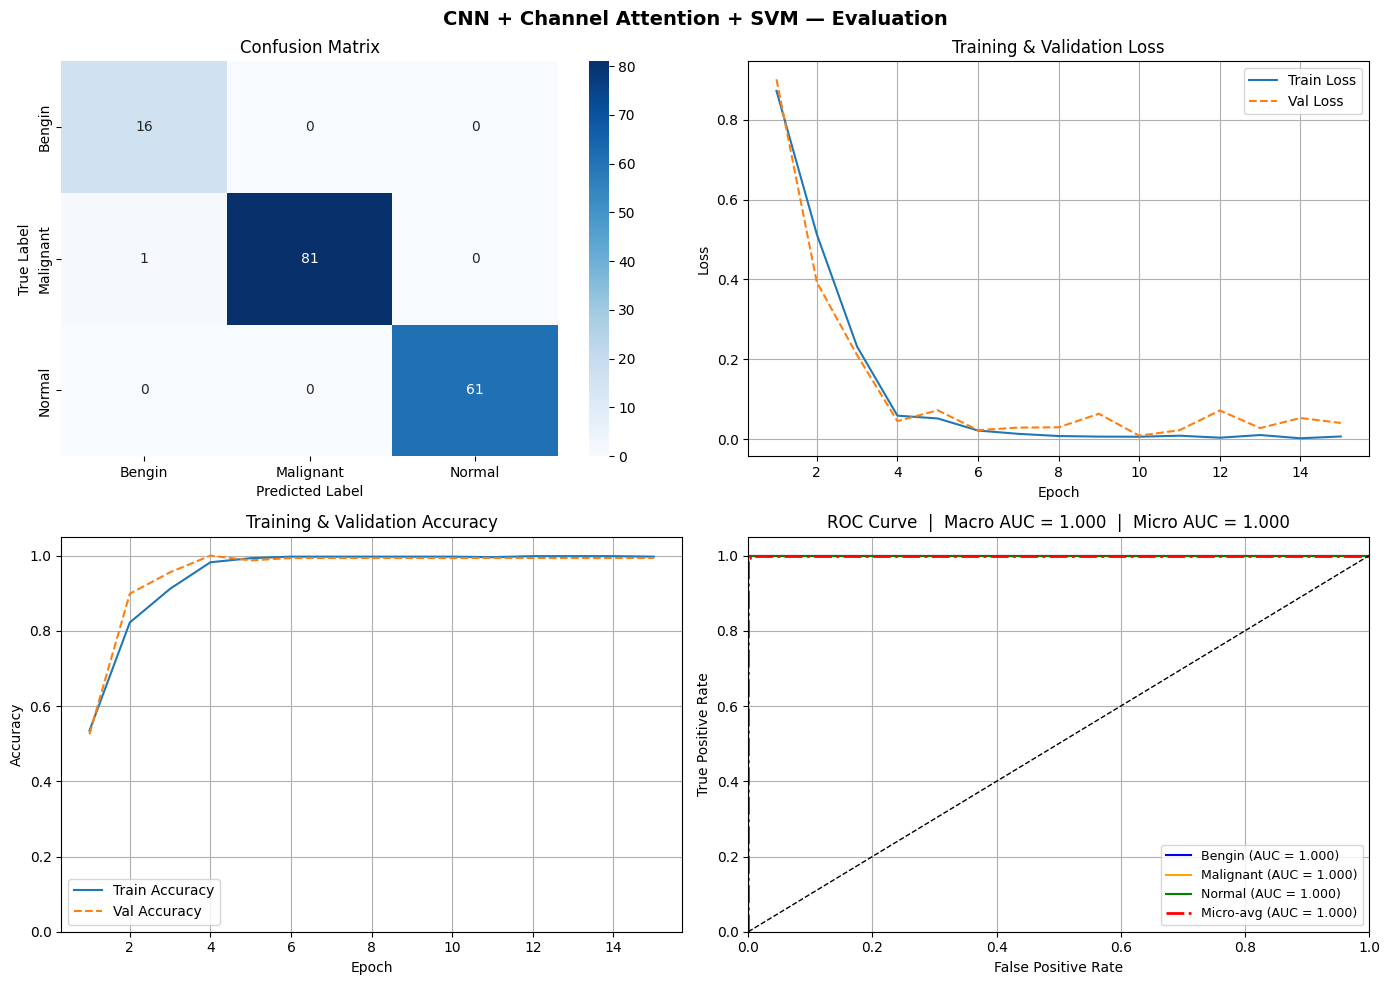

Macro AUC : 1.0000
Micro AUC : 1.0000


In [52]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

# ─────────────────────────────────────────────
# Persiapan Data
# ─────────────────────────────────────────────
y_pred       = svm_clf1.predict(X_test_scaled)
y_pred_proba = svm_clf1.predict_proba(X_test_scaled)
class_names  = ['Bengin', 'Malignant', 'Normal']  # Ganti sesuai labelmu

y_test_bin = label_binarize(y_test_int, classes=[0, 1, 2])

# AUC
auc_macro = roc_auc_score(y_test_bin, y_pred_proba, average='macro', multi_class='ovr')
auc_micro = roc_auc_score(y_test_bin, y_pred_proba, average='micro', multi_class='ovr')

# ROC per class
fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
for i in range(3):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc_micro_curve      = auc(fpr_micro, tpr_micro)

epochs_range = range(1, len(history.history['loss']) + 1)


# ─────────────────────────────────────────────
# Figure
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CNN + Channel Attention + SVM — Evaluation', fontsize=14, fontweight='bold')


# ── Plot 1: Confusion Matrix ──
cm = confusion_matrix(y_test_int, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')


# ── Plot 2: Loss ──
axes[0, 1].plot(epochs_range, history.history['loss'],     label='Train Loss')
axes[0, 1].plot(epochs_range, history.history['val_loss'], label='Val Loss', linestyle='--')
axes[0, 1].set_title('Training & Validation Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)


# ── Plot 3: Accuracy ──
axes[1, 0].plot(epochs_range, history.history['accuracy'],     label='Train Accuracy')
axes[1, 0].plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy', linestyle='--')
axes[1, 0].set_title('Training & Validation Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim([0, 1.05])
axes[1, 0].legend()
axes[1, 0].grid(True)


# ── Plot 4: ROC Curve ──
colors = ['blue', 'orange', 'green']
for i in range(3):
    axes[1, 1].plot(fpr_dict[i], tpr_dict[i], color=colors[i], linewidth=1.5,
                    label=f'{class_names[i]} (AUC = {roc_auc_dict[i]:.3f})')

axes[1, 1].plot(fpr_micro, tpr_micro, color='red', linewidth=2, linestyle='-.',
                label=f'Micro-avg (AUC = {roc_auc_micro_curve:.3f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1, 1].set_title(f'ROC Curve  |  Macro AUC = {auc_macro:.3f}  |  Micro AUC = {auc_micro:.3f}')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_xlim([0, 1])
axes[1, 1].set_ylim([0, 1.05])
axes[1, 1].legend(loc='lower right', fontsize=9)
axes[1, 1].grid(True)


plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Macro AUC : {auc_macro:.4f}")
print(f"Micro AUC : {auc_micro:.4f}")

In [53]:
import os
import joblib
from datetime import datetime

# ═══════════════════════════════════════════════════════════════════════════
# SAVE TRAINED MODELS TO NEW FOLDER
# ═══════════════════════════════════════════════════════════════════════════

# Create folder dengan timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_folder = f"saved_models_{timestamp}"
os.makedirs(save_folder, exist_ok=True)

print(f"═" * 70)
print(f"MENYIMPAN MODEL KE FOLDER: {save_folder}")
print(f"═" * 70)

try:
    # ─────────────────────────────────────────────
    # 1. Save CNN + Attention Model
    # ─────────────────────────────────────────────
    cnn_model_path = os.path.join(save_folder, "cnn_attention_model.keras")
    model2.save(cnn_model_path)
    print(f"\n✓ CNN + Attention Model saved:")
    print(f"  {cnn_model_path}")
    print(f"  Size: {os.path.getsize(cnn_model_path) / 1024:.2f} KB")

    # ─────────────────────────────────────────────
    # 2. Save Feature Extractor
    # ─────────────────────────────────────────────
    extractor_path = os.path.join(save_folder, "feature_extractor.keras")
    extractor.save(extractor_path)
    print(f"\n✓ Feature Extractor saved:")
    print(f"  {extractor_path}")
    print(f"  Size: {os.path.getsize(extractor_path) / 1024:.2f} KB")

    # ─────────────────────────────────────────────
    # 3. Save SVM Model
    # ─────────────────────────────────────────────
    svm_path = os.path.join(save_folder, "svm_classifier.pkl")
    joblib.dump(svm_clf1, svm_path)
    print(f"\n✓ SVM Classifier saved:")
    print(f"  {svm_path}")
    print(f"  Size: {os.path.getsize(svm_path) / 1024:.2f} KB")

    # ─────────────────────────────────────────────
    # 4. Save Scaler
    # ─────────────────────────────────────────────
    scaler_path = os.path.join(save_folder, "feature_scaler.pkl")
    joblib.dump(scaler, scaler_path)
    print(f"\n✓ Feature Scaler saved:")
    print(f"  {scaler_path}")
    print(f"  Size: {os.path.getsize(scaler_path) / 1024:.2f} KB")

    # ─────────────────────────────────────────────
    # 5. Save Training History
    # ─────────────────────────────────────────────
    import json
    history_dict = {
        'loss': [float(x) for x in history.history['loss']],
        'val_loss': [float(x) for x in history.history['val_loss']],
        'accuracy': [float(x) for x in history.history['accuracy']],
        'val_accuracy': [float(x) for x in history.history['val_accuracy']]
    }
    history_path = os.path.join(save_folder, "training_history.json")
    with open(history_path, 'w') as f:
        json.dump(history_dict, f, indent=2)
    print(f"\n✓ Training History saved:")
    print(f"  {history_path}")

    # ─────────────────────────────────────────────
    # 6. Save Model Information
    # ─────────────────────────────────────────────
    info_path = os.path.join(save_folder, "model_info.txt")
    with open(info_path, 'w') as f:
        f.write("=" * 70 + "\n")
        f.write("CNN + CHANNEL ATTENTION + SVM MODEL INFORMATION\n")
        f.write("=" * 70 + "\n\n")
        
        f.write("Model Components:\n")
        f.write("-" * 70 + "\n")
        f.write(f"1. CNN Feature Extractor: feature_extractor.keras\n")
        f.write(f"2. Attention Module: Channel Attention (Ratio=8)\n")
        f.write(f"3. Feature Dimension: 16\n")
        f.write(f"4. SVM Classifier: svm_classifier.pkl\n")
        f.write(f"5. SVM Kernel: RBF\n")
        f.write(f"6. Feature Scaler: feature_scaler.pkl\n\n")
        
        f.write("Training Configuration:\n")
        f.write("-" * 70 + "\n")
        f.write(f"Epochs: {len(history.history['loss'])}\n")
        f.write(f"Batch Size: 8\n")
        f.write(f"Final Train Loss: {history.history['loss'][-1]:.6f}\n")
        f.write(f"Final Val Loss: {history.history['val_loss'][-1]:.6f}\n")
        f.write(f"Final Train Accuracy: {history.history['accuracy'][-1]:.6f}\n")
        f.write(f"Final Val Accuracy: {history.history['val_accuracy'][-1]:.6f}\n\n")
        
        f.write("Data Information:\n")
        f.write("-" * 70 + "\n")
        f.write(f"Training Samples: {len(X_train)}\n")
        f.write(f"Validation Samples: {len(X_valid)}\n")
        f.write(f"Test Samples: {len(X_test)}\n")
        f.write(f"Number of Classes: {num_classes}\n")
        f.write(f"Classes: {', '.join(categories)}\n")
        
    print(f"\n✓ Model Information saved:")
    print(f"  {info_path}")

    # ─────────────────────────────────────────────
    # Summary dengan Tabel
    # ─────────────────────────────────────────────
    print(f"\n{'=' * 80}")
    print(f"SEMUA MODEL BERHASIL DISIMPAN")
    print(f"{'=' * 80}")
    print(f"\nFolder: {os.path.abspath(save_folder)}")
    
    # Buat tabel dengan pandas untuk tampilan lebih baik
    import pandas as pd
    
    # Hitung ukuran hanya untuk MODEL FILES (exclude metadata & docs)
    files_data = []
    total_size_bytes = 0
    
    model_files = {
        'cnn_attention_model.keras',
        'feature_extractor.keras',
        'svm_classifier.pkl'
    }
    
    for fname in sorted(os.listdir(save_folder)):
        if fname not in model_files:
            continue  # Skip non-model files
            
        fpath = os.path.join(save_folder, fname)
        fsize = os.path.getsize(fpath)
        total_size_bytes += fsize
        
        if fsize < 1024:
            size_kb = f"{fsize} B"
        elif fsize < 1024*1024:
            size_kb = f"{fsize/1024:.2f} KB"
        else:
            size_kb = f"{fsize/(1024*1024):.2f} MB"
        
        files_data.append({
            'Nama File': fname,
            'Ukuran': size_kb,
            'Ukuran (Bytes)': fsize
        })
    
    # Tambah baris total untuk MODEL saja
    if total_size_bytes < 1024*1024:
        total_str = f"{total_size_bytes/1024:.2f} KB"
    else:
        total_str = f"{total_size_bytes/(1024*1024):.2f} MB"
    
    files_data.append({
        'Nama File': '═══ TOTAL MODEL ═══',
        'Ukuran': total_str,
        'Ukuran (Bytes)': total_size_bytes
    })
    
    df = pd.DataFrame(files_data)
    
    print(f"\nTABEL UKURAN MODEL:")
    print(f"{df.to_string(index=False)}")
    print(f"\n{'=' * 80}")
    print(f"Catatan: Ukuran di atas hanya mencakup file model produksi.")
    print(f"File tambahan yang juga tersimpan:")
    print(f"  • feature_scaler.pkl (999 B) - untuk preprocessing")
    print(f"  • training_history.json (1.48 KB) - dokumentasi training")
    print(f"  • model_info.txt (986 B) - informasi model")

except Exception as e:
    print(f"\n❌ Error saat menyimpan model: {str(e)}")

══════════════════════════════════════════════════════════════════════
MENYIMPAN MODEL KE FOLDER: saved_models_20260427_133743
══════════════════════════════════════════════════════════════════════

✓ CNN + Attention Model saved:
  saved_models_20260427_133743\cnn_attention_model.keras
  Size: 38187.68 KB

✓ Feature Extractor saved:
  saved_models_20260427_133743\feature_extractor.keras
  Size: 12739.02 KB

✓ SVM Classifier saved:
  saved_models_20260427_133743\svm_classifier.pkl
  Size: 8.94 KB

✓ Feature Scaler saved:
  saved_models_20260427_133743\feature_scaler.pkl
  Size: 0.98 KB

✓ Training History saved:
  saved_models_20260427_133743\training_history.json

✓ Model Information saved:
  saved_models_20260427_133743\model_info.txt

SEMUA MODEL BERHASIL DISIMPAN

Folder: d:\bintang\saved_models_20260427_133743

TABEL UKURAN MODEL:
                Nama File   Ukuran  Ukuran (Bytes)
cnn_attention_model.keras 37.29 MB        39104184
  feature_extractor.keras 12.44 MB        13044760


In [54]:
import pandas as pd

# ═══════════════════════════════════════════════════════════════════════════
# TABEL RINGKASAN PERFORMA
# ═══════════════════════════════════════════════════════════════════════════
perf_data = {
    "Metric": [
        "Feature Extraction Time",
        "SVM Training Time",
        "Inference Time",
        "Test Accuracy"
    ],
    "Value": [
        f"{feature_extraction_time:.4f} s",
        f"{svm_training_time:.4f} s",
        f"{inference_time:.4f} s",
        f"{test_accuracy:.4f}"
    ]
}
perf_df = pd.DataFrame(perf_data)

print("═" * 50)
print("RINGKASAN PERFORMA".center(50))
print("═" * 50)
print(perf_df.to_string(index=False))
print("═" * 50)


# ═══════════════════════════════════════════════════════════════════════════
# TABEL UKURAN MODEL / ARTEFAK
# ═══════════════════════════════════════════════════════════════════════════
try:
    cnn_size = os.path.getsize(cnn_model_path) / 1024
    extractor_size = os.path.getsize(extractor_path) / 1024
    svm_size = os.path.getsize(svm_path) / 1024
    scaler_size = os.path.getsize(scaler_path) / 1024
    total_size = cnn_size + extractor_size + svm_size + scaler_size

    size_data = {
        "Komponen": [
            "CNN Attention (main)",
            "CNN Feature Extractor",
            "SVM Classifier",
            "Feature Scaler",
            "TOTAL"
        ],
        "Awal (KB)": [
            f"{cnn_size:.2f}",
            f"{extractor_size:.2f}",
            f"{svm_size:.2f}",
            f"{scaler_size:.2f}",
            f"{total_size:.2f}"
        ]
    }
    size_df = pd.DataFrame(size_data)

    print("\n\n" + "═" * 50)
    print("UKURAN MODEL / ARTEFAK".center(50))
    print("═" * 50)
    print(size_df.to_string(index=False))
    print("═" * 50)

except NameError:
    print("\nCould not generate model size table. Please ensure the model saving cell has been run.")
except FileNotFoundError as e:
    print(f"\nCould not find a model file, skipping size table: {e}")

══════════════════════════════════════════════════
                RINGKASAN PERFORMA                
══════════════════════════════════════════════════
                 Metric    Value
Feature Extraction Time 1.4292 s
      SVM Training Time 0.0102 s
         Inference Time 0.2326 s
          Test Accuracy   0.9937
══════════════════════════════════════════════════


══════════════════════════════════════════════════
              UKURAN MODEL / ARTEFAK              
══════════════════════════════════════════════════
             Komponen Awal (KB)
 CNN Attention (main)  38187.68
CNN Feature Extractor  12739.02
       SVM Classifier      8.94
       Feature Scaler      0.98
                TOTAL  50936.62
══════════════════════════════════════════════════
